# Model 2: XGBoost + Optuna tuning

## Setup

In [1]:
%pip install optuna


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append('..')

In [4]:
import pandas as pd
import numpy as np

from src.features import add_all_features
from src.evaluation import train_and_evaluate, quick_log_loss
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import optuna

### Load data, drop nulls, generate features

In [5]:
raw_df = pd.read_csv('/Users/nadiiababanska/Desktop/claude_coowork/ML_final_project/quora_question_pairs_train_.csv', index_col=0)

In [6]:
raw_df = raw_df.dropna(subset=['question1', 'question2']).copy()

In [7]:
add_all_features(raw_df, q1_col="question1", q2_col="question2")

,qid1,qid2,question1,question2,is_duplicate,question1_len,question2_len,len_dif,common_words,jaccard_similarity,word_match_share,bigrams_common,bigram_jaccard_similarity,bigram_word_match_share,cosine_similarity
id,,,,,,,,,,,,,,,
332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0,47,81,-34,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
196656,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,62,55,7,3.0,0.600000,0.375000,1.0,0.200000,0.166667,0.827243
113125,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,32,78,-46,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.149953
266232,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,51,42,9,2.0,0.250000,0.200000,1.0,0.142857,0.125000,0.345153
122738,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1,159,68,91,4.0,0.235294,0.190476,1.0,0.055556,0.052632,0.233961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111701,182893,182894,What are the major stereotypes people have abo...,What are the major stereotypes people have abo...,0,90,89,1,5.0,0.714286,0.416667,3.0,0.428571,0.300000,0.736964
90934,152504,152505,What are some of the best and most creative pr...,Which is one of the worst and most insensible ...,0,84,86,-2,1.0,0.111111,0.100000,0.0,0.000000,0.000000,0.415535
363857,493887,493888,Why is there a road named Aurangzeb in Delhi?,How do you justify naming a road after Aurangzeb?,0,45,49,-4,1.0,0.142857,0.125000,0.0,0.000000,0.000000,0.569104


### Train/validation split

In [8]:
# deviding of train daset on train and val
X = raw_df.drop(columns=['is_duplicate'])
y = raw_df['is_duplicate']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#### Model 2 - XGBoost baseline

In [9]:
feature_cols = ['question1_len', 'question2_len', 'len_dif', 'common_words',
                 'jaccard_similarity', 'word_match_share', 'bigrams_common',
                 'bigram_jaccard_similarity', 'bigram_word_match_share', 'cosine_similarity']

X_train_xgb = X_train[feature_cols]
X_val_xgb = X_val[feature_cols]

model: Model 2 - XGBoost baseline

threshold: None

params: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}

train_time_sec: 0

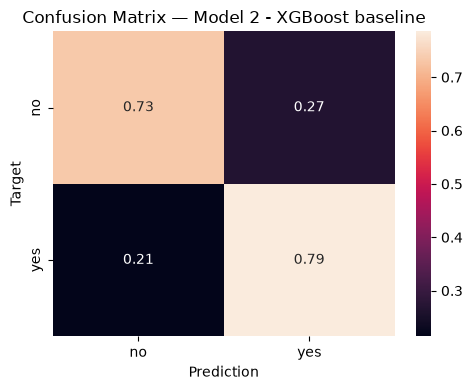

In [10]:
model_xgb = XGBClassifier(random_state=42)
model_xgb_fitted, results_model_2 = train_and_evaluate(model_xgb, X_train_xgb, y_train, X_val_xgb, y_val, 'Model 2 - XGBoost baseline', threshold=None)

#### XGBoost parameters tuning with Optuna

In [11]:
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
    }
    model = XGBClassifier(**params)
    return quick_log_loss(model, X_train_xgb, y_train, X_val_xgb, y_val)

In [12]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

[I 2026-07-24 23:59:58,466] A new study created in memory with name: no-name-b10b1c6b-4585-48f1-9f58-efde5185e69f
[I 2026-07-24 23:59:59,318] Trial 0 finished with value: 0.46243566274642944 and parameters: {'max_depth': 5, 'learning_rate': 0.020677232213671955, 'n_estimators': 190, 'subsample': 0.7655415530111231, 'colsample_bytree': 0.7111658895772006}. Best is trial 0 with value: 0.46243566274642944.
[I 2026-07-25 00:00:00,472] Trial 1 finished with value: 0.45142972469329834 and parameters: {'max_depth': 4, 'learning_rate': 0.10704703779672653, 'n_estimators': 332, 'subsample': 0.7868047542309253, 'colsample_bytree': 0.7100143629312258}. Best is trial 1 with value: 0.45142972469329834.
[I 2026-07-25 00:00:00,927] Trial 2 finished with value: 0.45798853039741516 and parameters: {'max_depth': 3, 'learning_rate': 0.16005177930500447, 'n_estimators': 135, 'subsample': 0.8228376508513532, 'colsample_bytree': 0.7309251568897717}. Best is trial 1 with value: 0.45142972469329834.
[I 2026-0

In [13]:
print(study.best_params)
print(study.best_value)

{'max_depth': 7, 'learning_rate': 0.05193751160284111, 'n_estimators': 454, 'subsample': 0.8294678193741134, 'colsample_bytree': 0.9928021028272725}
0.4473656117916107


model: Model 2: XGBoost (Optuna-tuned)

threshold: None

params: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.9928021028272725, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05193751160284111, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 7, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 454, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8294678193741134, 'tree_method': None, 'validate_parameters':

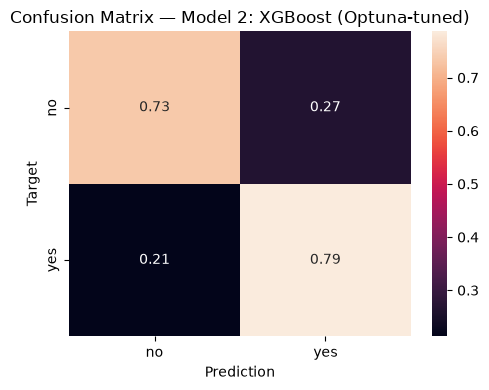

In [14]:
best_xgb_model = XGBClassifier(**study.best_params, random_state=42)
model_xgb_tuned, results_model_2_tuned = train_and_evaluate(
    best_xgb_model, X_train_xgb, y_train, X_val_xgb, y_val,
    'Model 2: XGBoost (Optuna-tuned)'
)